<a href="https://colab.research.google.com/github/Rumaisa30/MCF-Launchpad-Project/blob/main/Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Target column successfully identified/renamed to 'income'.
Dataframe size after cleaning missing values: 45222 rows.
Dataframe size after cleaning values: 45222 rows.

======= BEFORE BALANCING SUMMARY (Initial Bias) ======

Income distribution by Gender (Before):
income     <=50K      >50K
sex                       
Female  0.886424  0.113576
Male    0.687523  0.312477

Income distribution by Race (Before):
income                 <=50K      >50K
race                                  
Amer-Indian-Eskimo  0.878161  0.121839
Asian-Pac-Islander  0.716807  0.283193
Black               0.873699  0.126301
Other               0.872521  0.127479
White               0.737629  0.262371


/tmp/ipython-input-3313731545.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_bias_before = df.groupby('sex')['income'].value_counts(normalize=True).unstack()
/tmp/ipython-input-3313731545.py:67: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  race_bias_before = df.groupby('race')['income'].value_counts(normalize=True).unstack()
/tmp/ipython-input-3313731545.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  


--- Running Intersectional Oversampling (Race x Income) ---
Largest group size (Race x Income): 28696. Upsampling all 10 groups to this size.
✅ Dataset balanced by race and income label. New size: 286960 rows.

======= AFTER BALANCING SUMMARY (Demographic Parity Achieved) ======

Income distribution by Gender (After):
income     <=50K      >50K
sex                       
Female  0.670368  0.329632
Male    0.424224  0.575776

Income distribution by Race (After):
income              <=50K  >50K
race                           
Amer-Indian-Eskimo    0.5   0.5
Asian-Pac-Islander    0.5   0.5
Black                 0.5   0.5
Other                 0.5   0.5
White                 0.5   0.5


/tmp/ipython-input-3313731545.py:120: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_bias_after = df_balanced.groupby('sex')['income'].value_counts(normalize=True).unstack()
/tmp/ipython-input-3313731545.py:125: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  race_bias_after = df_balanced.groupby('race')['income'].value_counts(normalize=True).unstack()


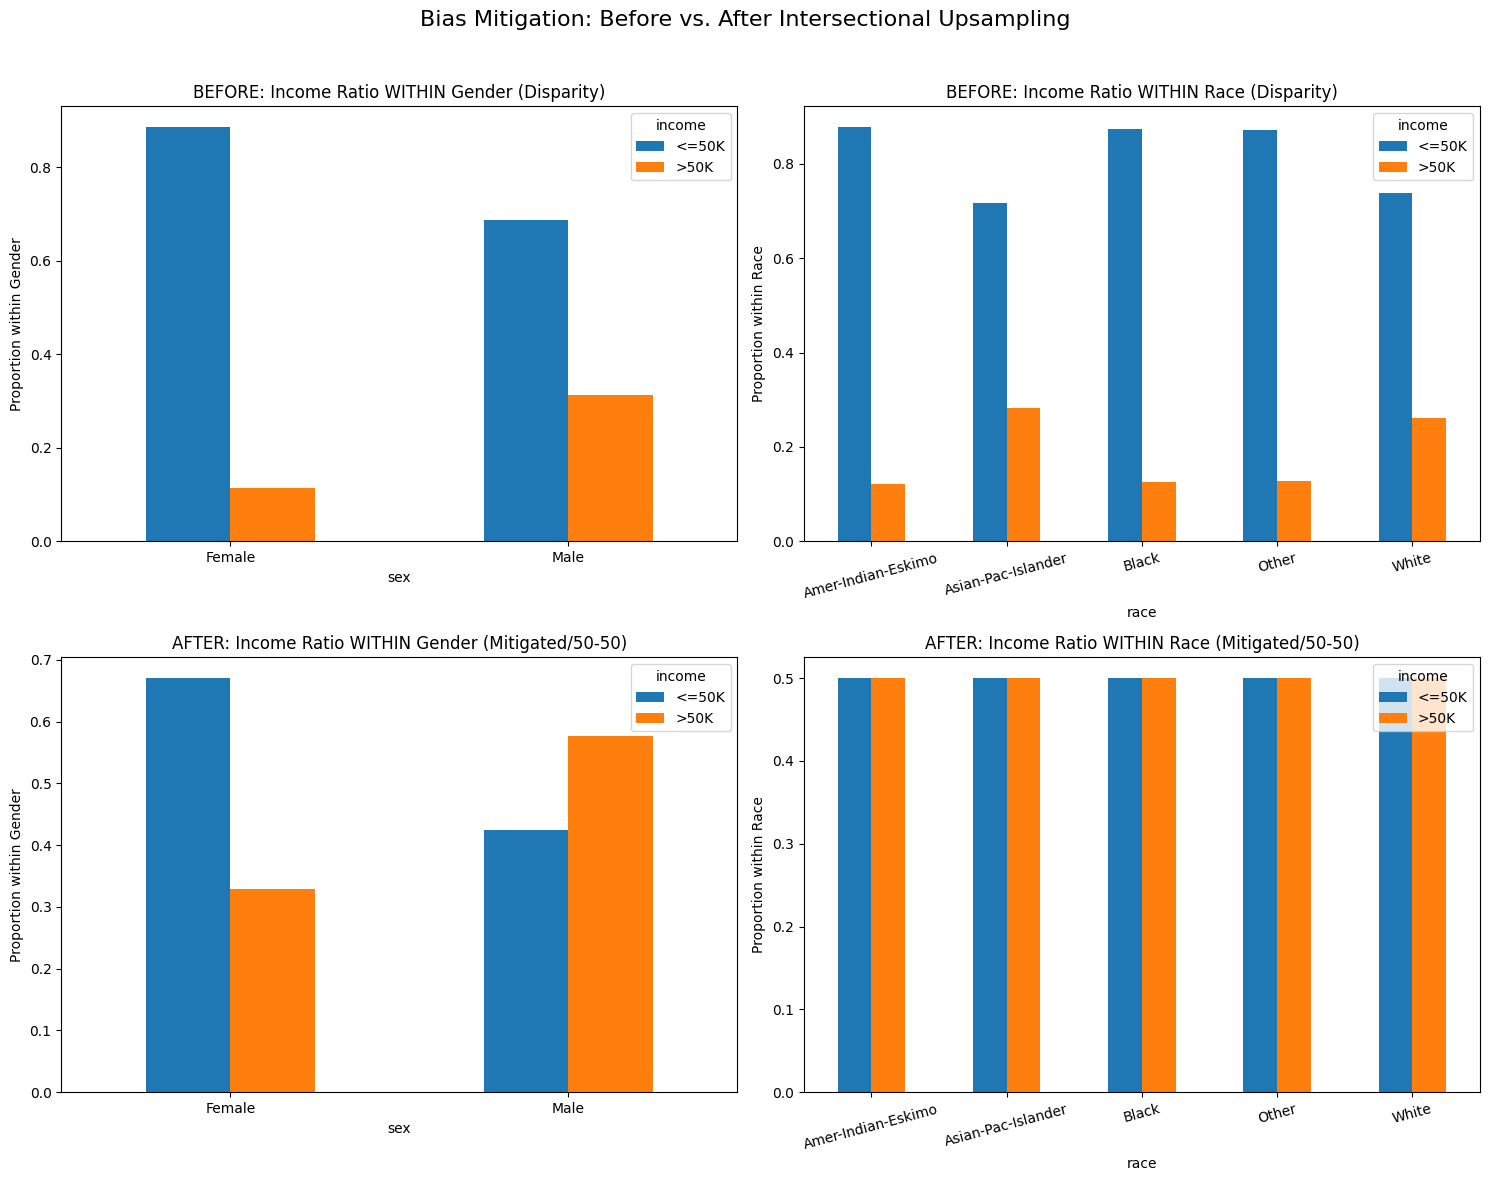


Columns after removing sensitive attributes (from BALANCED data):
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

✅ Fairer dataset saved as 'adult_fair_mitigated_final.csv'!


In [ ]:
!pip install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import resample
from ucimlrepo import fetch_ucirepo

%matplotlib inline

# ===============================================
# 2️⃣ Load Dataset and Prepare Structure
# ===============================================
# Fetch dataset directly from UCI Machine Learning Repository
adult = fetch_ucirepo(id=2)

# Create a DataFrame from features
df = adult.data.original.copy()

# Extract target data as a simple list of strings
# Ensure each element is a string and clean it up (remove periods and extra spaces)
# .squeeze() to get a Series, .tolist() to get a list, then stringify and clean each element
income_values = [str(x).replace('.', '').strip() for x in adult.data.targets.squeeze().tolist()]

# Add 'income' as a new column to the DataFrame
df['income'] = income_values

# Clean other column names (remove extra spaces and dots)
df.columns = [col.strip().replace('.', '_') for col in df.columns]

# Now, 'income' is guaranteed to be a column of simple strings
print(f"Target column successfully identified/renamed to 'income'.")


# 3️⃣ Clean Up Categorical Formatting
# ===============================================
# Handle missing values first, which are encoded as '?'
df = df.replace('?', np.nan).dropna()
print(f"Dataframe size after cleaning missing values: {len(df)} rows.")

# List of all categorical columns to clean
categorical_cols = ['sex', 'race', 'income']

# This loop will now primarily affect 'sex' and 'race', as 'income' is already cleaned
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: str(x).replace('.', '').strip())
    else:
        print(f"Warning: Column '{col}' not found in DataFrame.")

print(f"Dataframe size after cleaning values: {len(df)} rows.")
 # Ensure columns are treated as simple strings/categories for plotting/grouping
df['sex'] = df['sex'].astype('category')
df['race'] = df['race'].astype('category')
df['income'] = df['income'].astype('category')
# ===============================================
# 4️⃣ Inspect Bias BEFORE Balancing
# ===============================================
print("\n======= BEFORE BALANCING SUMMARY (Initial Bias) ======")

# Calculate original gender bias: Proportion of >50K vs. <=50K by Sex
gender_bias_before = df.groupby('sex')['income'].value_counts(normalize=True).unstack()
print("\nIncome distribution by Gender (Before):")
print(gender_bias_before)

# Calculate original racial bias: Proportion of >50K vs. <=50K by Race
race_bias_before = df.groupby('race')['income'].value_counts(normalize=True).unstack()
print("\nIncome distribution by Race (Before):")
print(race_bias_before)

# ===============================================
# 5️⃣ & 6️⃣ Plot Bias BEFORE Balancing (Shows the problem)
# ===============================================
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.suptitle('Bias Mitigation: Before vs. After Intersectional Upsampling', fontsize=16)

# --- BEFORE BALANCING (Gender Bias) ---
gender_bias_before.plot(
    kind='bar', ax=axes[0, 0], title='BEFORE: Income Ratio WITHIN Gender (Disparity)'
)
axes[0, 0].set_ylabel('Proportion within Gender')
axes[0, 0].tick_params(axis='x', rotation=0)

# --- BEFORE BALANCING (Race Bias) ---
race_bias_before.plot(
    kind='bar', ax=axes[0, 1], title='BEFORE: Income Ratio WITHIN Race (Disparity)'
)
axes[0, 1].set_ylabel('Proportion within Race')
axes[0, 1].tick_params(axis='x', rotation=15)

# ===============================================
# 7️⃣ Intersectional Bias Mitigation (The CHANGE)
# ===============================================
print("\n--- Running Intersectional Oversampling (Race x Income) ---")

# Group by the intersection of 'race' and 'income'
groups = df.groupby(['race', 'income'])
all_groups = [groups.get_group(group) for group in groups.groups]

# Find the largest group size
max_size = max(len(group) for group in all_groups)
print(f"Largest group size (Race x Income): {max_size}. Upsampling all {len(all_groups)} groups to this size.")

# Upsample all groups to the maximum size
balanced_groups = []
for group in all_groups:
    group_bal = resample(group, replace=True, n_samples=max_size, random_state=42)
    balanced_groups.append(group_bal)

# Combine into one balanced DataFrame
df_balanced = pd.concat(balanced_groups)
print(f"✅ Dataset balanced by race and income label. New size: {len(df_balanced)} rows.")

# ===============================================
# 8️⃣ Inspect Bias AFTER Balancing (Shows the fix)
# ===============================================
print("\n======= AFTER BALANCING SUMMARY (Demographic Parity Achieved) ======")

# Calculate gender bias AFTER balancing
gender_bias_after = df_balanced.groupby('sex')['income'].value_counts(normalize=True).unstack()
print("\nIncome distribution by Gender (After):")
print(gender_bias_after) # Expected to show ~0.5 for both income classes

# Calculate race bias AFTER balancing
race_bias_after = df_balanced.groupby('race')['income'].value_counts(normalize=True).unstack()
print("\nIncome distribution by Race (After):")
print(race_bias_after) # Expected to show ~0.5 for both income classes

# ===============================================
# 9️⃣ Plot Bias AFTER Balancing (Visibly shows the change)
# ===============================================

# --- AFTER BALANCING (Gender Bias) ---
gender_bias_after.plot(
    kind='bar', ax=axes[1, 0], title='AFTER: Income Ratio WITHIN Gender (Mitigated/50-50)'
)
axes[1, 0].set_ylabel('Proportion within Gender')
axes[1, 0].tick_params(axis='x', rotation=0)

# --- AFTER BALANCING (Race Bias) ---
race_bias_after.plot(
    kind='bar', ax=axes[1, 1], title='AFTER: Income Ratio WITHIN Race (Mitigated/50-50)'
)
axes[1, 1].set_ylabel('Proportion within Race')
axes[1, 1].tick_params(axis='x', rotation=15)

# Adjust layout and display all plots
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 🔟 Prepare Final Dataset (Ready for Model Training)
df_fair = df_balanced.drop(columns=['sex', 'race'])
print("\nColumns after removing sensitive attributes (from BALANCED data):")
print(df_fair.columns.tolist())

df_fair.to_csv("adult_fair_mitigated_final.csv", index=False)
print("\n✅ Fairer dataset saved as 'adult_fair_mitigated_final.csv'!")

In [ ]:
!pip install ucimlrepo